## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [19]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision.transforms import InterpolationMode


We always check that we are running on a GPU

In [2]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on GPU.


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [3]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='./hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [4]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])

batch_size = 64
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=3)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)

Let's look at some images from our data 

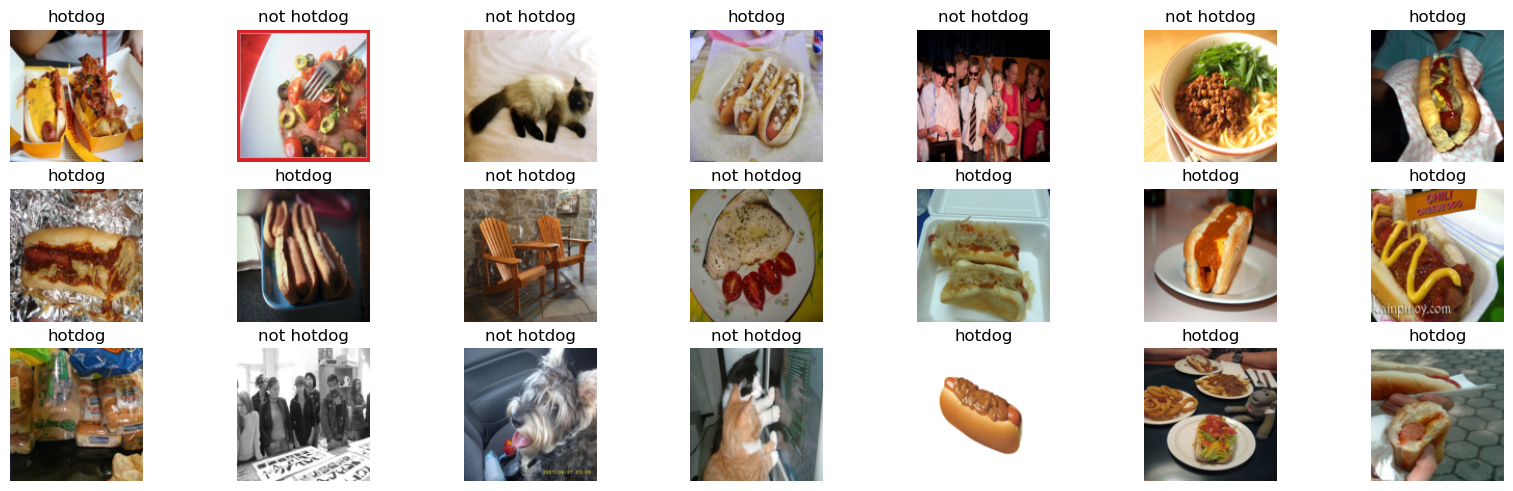

In [5]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


Now create a model and train it!


In [6]:
def train(model, optimizer, num_epochs=10, train_loader=train_loader):
    def loss_fun(output, target):
        # return F.nll_loss(output, target)
        return F.cross_entropy(output, target)
    out_dict = {'train_acc': [],
              'test_acc': [],
              'train_loss': [],
              'test_loss': []}
  
    for epoch in tqdm(range(num_epochs), unit='epoch'):
        model.train()
        #For each epoch
        train_correct = 0
        train_loss = []
        for minibatch_no, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):
            data, target = data.to(device), target.to(device)
            #Zero the gradients computed for each weight
            optimizer.zero_grad()
            #Forward pass your image through the network
            output = model(data)
            #Compute the loss
            loss = loss_fun(output, target)
            #Backward pass through the network
            loss.backward()
            #Update the weights
            optimizer.step()

            train_loss.append(loss.item())
            #Compute how many were correctly classified
            predicted = output.argmax(1)
            train_correct += (target==predicted).sum().cpu().item()
        #Comput the test accuracy
        test_loss = []
        test_correct = 0
        model.eval()
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            with torch.no_grad():
                output = model(data)
            test_loss.append(loss_fun(output, target).cpu().item())
            predicted = output.argmax(1)
            test_correct += (target==predicted).sum().cpu().item()
        out_dict['train_acc'].append(train_correct/len(trainset))
        out_dict['test_acc'].append(test_correct/len(testset))
        out_dict['train_loss'].append(np.mean(train_loss))
        out_dict['test_loss'].append(np.mean(test_loss))
        print(f"Loss train: {np.mean(train_loss):.3f}\t test: {np.mean(test_loss):.3f}\t",
              f"Accuracy train: {out_dict['train_acc'][-1]*100:.1f}%\t test: {out_dict['test_acc'][-1]*100:.1f}%")
    return out_dict

In [7]:
def plot_training(out_dict):
    # X-axis = epoch numbers
    epochs = np.arange(1, len(out_dict['train_acc']) + 1)
    
    # --- Accuracy ---
    plt.figure(figsize=(6,4))
    plt.plot(epochs, np.array(out_dict['train_acc']) * 100, marker='o', label='Train accuracy')
    plt.plot(epochs, np.array(out_dict['test_acc']) * 100, marker='o', label='Test accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy vs. Epoch')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- Loss ---
    plt.figure(figsize=(6,4))
    plt.plot(epochs, out_dict['train_loss'], marker='o', label='Train loss')
    plt.plot(epochs, out_dict['test_loss'], marker='o', label='Test loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs. Epoch')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
class TinyHotdogNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True)
            )
        self.features = nn.Sequential(
            block(3, 32), block(32, 32), nn.MaxPool2d(2),   # 128->64
            block(32, 64), block(64, 64), nn.MaxPool2d(2),  # 64->32
            block(64,128), block(128,128), nn.MaxPool2d(2), # 32->16
            block(128,256), nn.Dropout(0.2)
        )
        self.head = nn.Sequential(
            # nn.AdaptiveAvgPool2d(1),
            # nn.Linear(16*16*256, 256),
            nn.Flatten(),
            nn.Linear(16*16*256, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)

In [9]:
model = TinyHotdogNet().to(device)
# criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


  0%|          | 0/40 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 2.800	 test: 0.678	 Accuracy train: 55.7%	 test: 56.7%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.601	 test: 0.586	 Accuracy train: 69.8%	 test: 70.7%


...

Loss train: 0.008	 test: 1.180	 Accuracy train: 99.9%	 test: 79.2%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.013	 test: 1.325	 Accuracy train: 99.5%	 test: 78.7%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.022	 test: 1.556	 Accuracy train: 99.3%	 test: 76.0%


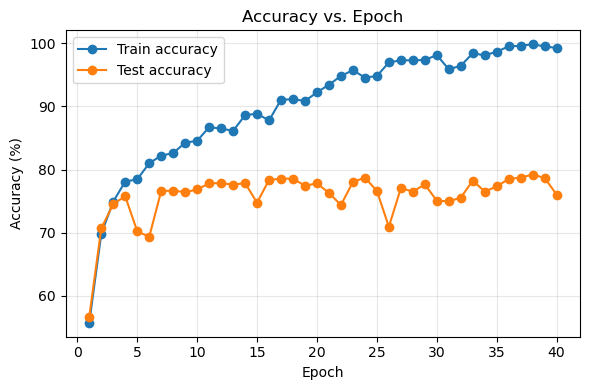

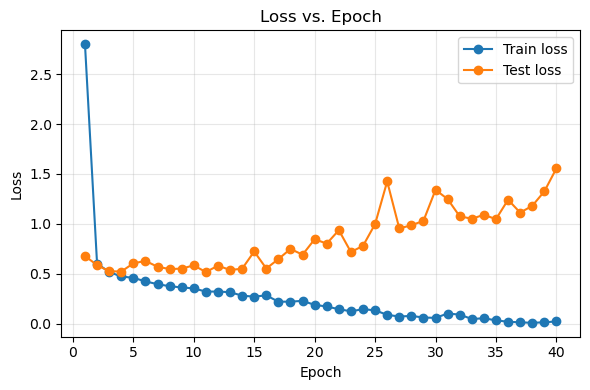

In [10]:
out_dict = train(model, optimizer, 40)
plot_training(out_dict)

In [21]:
# train_transform = transforms.Compose([
#     transforms.Resize((128,128)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.RandomRotation(30),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2),
#     transforms.ToTensor()
# ])
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0), ratio=(0.9, 1.1),
                                 interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
])
batch_size = 64
trainset_aug = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader_aug = DataLoader(trainset_aug, batch_size=batch_size, shuffle=True, num_workers=3)

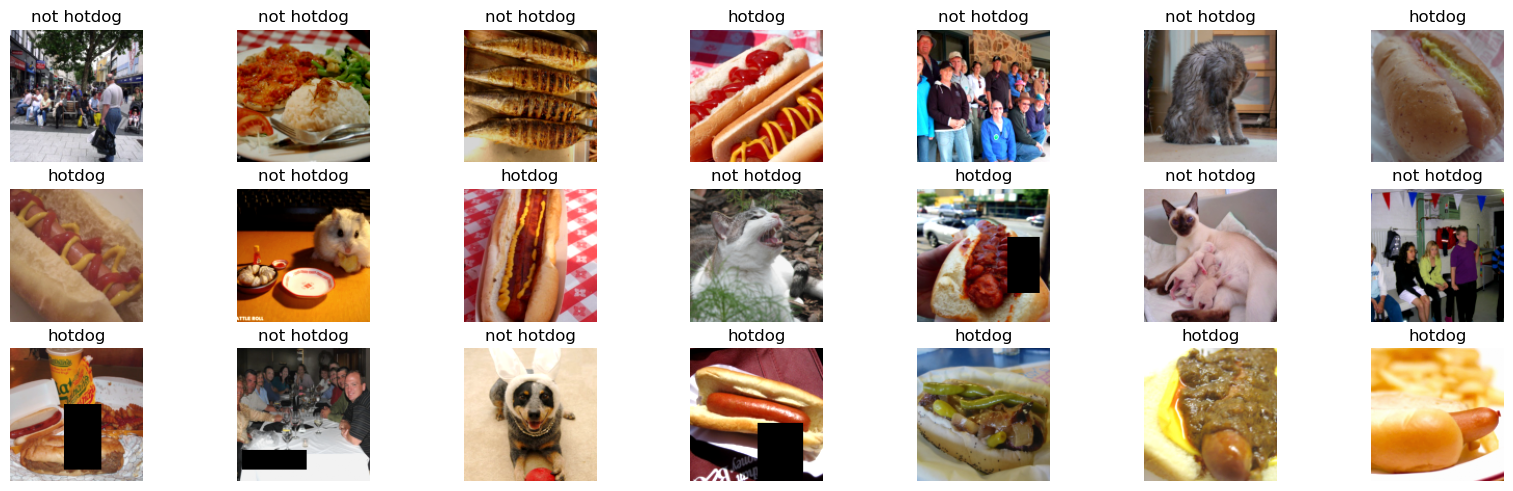

In [22]:
images, labels = next(iter(train_loader_aug))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')

  0%|          | 0/40 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 2.730	 test: 0.851	 Accuracy train: 56.5%	 test: 48.2%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.620	 test: 0.698	 Accuracy train: 71.8%	 test: 69.3%


...

Loss train: 0.222	 test: 0.588	 Accuracy train: 91.2%	 test: 79.9%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.249	 test: 0.568	 Accuracy train: 90.0%	 test: 79.4%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.246	 test: 0.549	 Accuracy train: 89.9%	 test: 80.2%


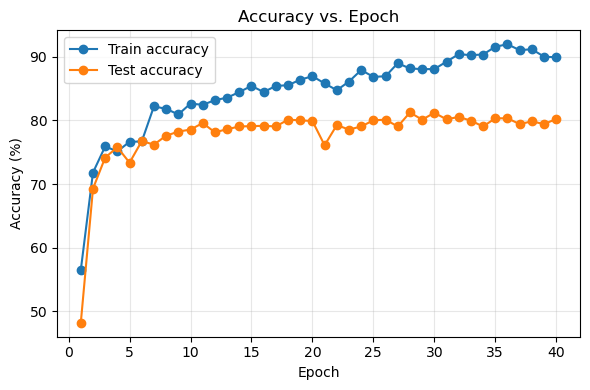

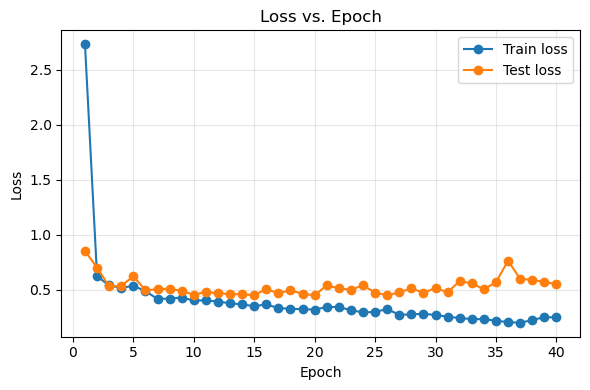

In [23]:
model_aug = TinyHotdogNet().to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
out_dict_aug = train(model_aug, optimizer_aug, 40, train_loader=train_loader_aug)
plot_training(out_dict_aug)

In [26]:
def plot_compare_trainings(dict1, dict2, title, labels, test=True):
    epochs = np.arange(1, len(out_dict['train_acc']) + 1)
    
    # --- Accuracy ---
    plt.figure(figsize=(6,4))
    if test:
        plt.plot(epochs, np.array(dict1['test_acc']) * 100, marker='o', label=labels[0])
        plt.plot(epochs, np.array(dict2['test_acc']) * 100, marker='o', label=labels[1])
    else:
        plt.plot(epochs, np.array(dict1['train_acc']) * 100, marker='o', label=labels[0])
        plt.plot(epochs, np.array(dict2['train_acc']) * 100, marker='o', label=labels[1])
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy vs. Epoch ' + str(title))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- Loss ---
    plt.figure(figsize=(6,4))
    if test:
        plt.plot(epochs, dict1['test_loss'], marker='o', label=labels[0])
        plt.plot(epochs, dict2['test_loss'], marker='o', label=labels[1])
    else:
        plt.plot(epochs, dict1['train_loss'], marker='o', label=labels[0])
        plt.plot(epochs, dict2['train_loss'], marker='o', label=labels[1])
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs. Epoch ' + str(title))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

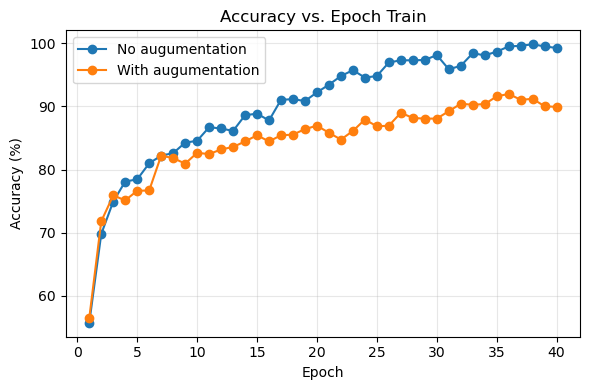

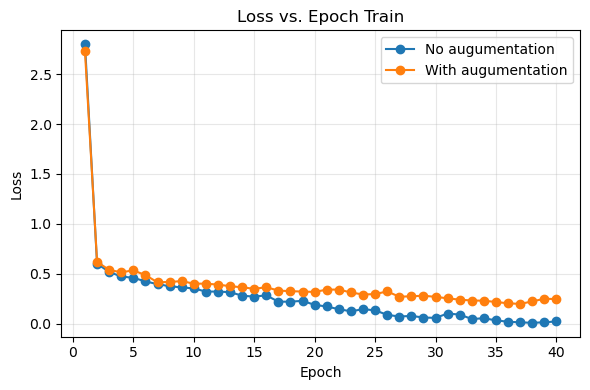

In [27]:
# epochs = np.arange(1, len(out_dict['train_acc']) + 1)

# # --- Accuracy ---
# plt.figure(figsize=(6,4))
# plt.plot(epochs, np.array(out_dict['train_acc']) * 100, marker='o', label='No augumentation')
# plt.plot(epochs, np.array(out_dict_aug['train_acc']) * 100, marker='o', label='With augumentation')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy (%)')
# plt.title('Accuracy vs. Epoch Train')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

# # --- Loss ---
# plt.figure(figsize=(6,4))
# plt.plot(epochs, out_dict['train_loss'], marker='o', label='No augumentation')
# plt.plot(epochs, out_dict_aug['train_loss'], marker='o', label='With augumentation')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Loss vs. Epoch Train')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()
plot_compare_trainings(out_dict, out_dict_aug, "Train", ['No augumentation', 'With augumentation'], test=False)

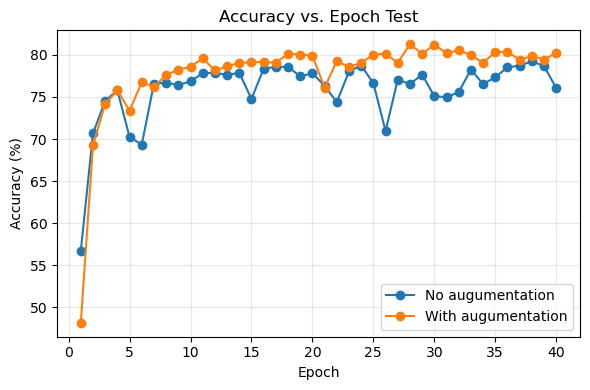

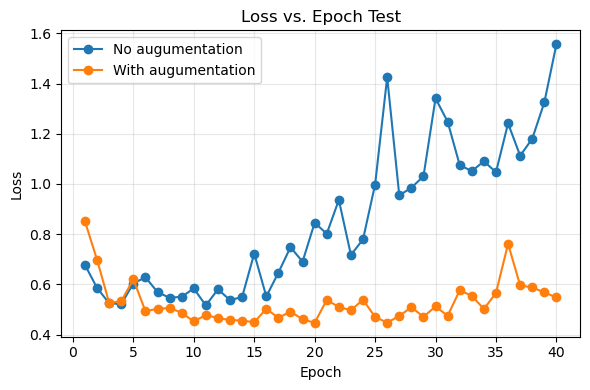

In [28]:
# epochs = np.arange(1, len(out_dict['test_acc']) + 1)

# # --- Accuracy ---
# plt.figure(figsize=(6,4))
# plt.plot(epochs, np.array(out_dict['test_acc']) * 100, marker='o', label='No augumentation')
# plt.plot(epochs, np.array(out_dict_aug['test_acc']) * 100, marker='o', label='With augumentation')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy (%)')
# plt.title('Accuracy vs. Epoch Test')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

# # --- Loss ---
# plt.figure(figsize=(6,4))
# plt.plot(epochs, out_dict['test_loss'], marker='o', label='No augumentation')
# plt.plot(epochs, out_dict_aug['test_loss'], marker='o', label='With augumentation')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Loss vs. Epoch Test')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()
plot_compare_trainings(out_dict, out_dict_aug, "Test", ['No augumentation', 'With augumentation'], test=True)

In [17]:
model_sgd = TinyHotdogNet().to(device)
optimizer_sgd = torch.optim.SGD(model.parameters(), lr=0.001)
out_dict_sgd = train(model_sgd, optimizer_sgd, 80, train_loader=train_loader_aug)
plot_training(out_dict_sgd)

  0%|          | 0/80 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.696	 test: 0.690	 Accuracy train: 50.2%	 test: 52.0%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.697	 test: 0.695	 Accuracy train: 49.1%	 test: 47.9%


...

Loss train: 0.700	 test: 0.695	 Accuracy train: 47.6%	 test: 47.2%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.697	 test: 0.695	 Accuracy train: 48.7%	 test: 47.5%


  0%|          | 0/32 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
plot_compare_trainings(out_dict_sgd, out_dict_aug, title="optimizers", labels=["SGD", "Adam"])